In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


**LOADING THE DATASET**

In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())

Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Ch

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


The dataset contains Tesla delivery, production, pricing, battery, range, CO2 savings, and charging infrastructure information from 2015–2025 across multiple regions and vehicle models.

In [3]:
print("\nDuplicate Rows")
print(df.duplicated().sum())

print("Missing Values")
print(df.isnull().sum())


Duplicate Rows
0
Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64



The dataset was checked for missing values and duplicate records before analysis. Any identified issues should be handled before model training.

# EDA Charts Analysis

**deliveries by model**

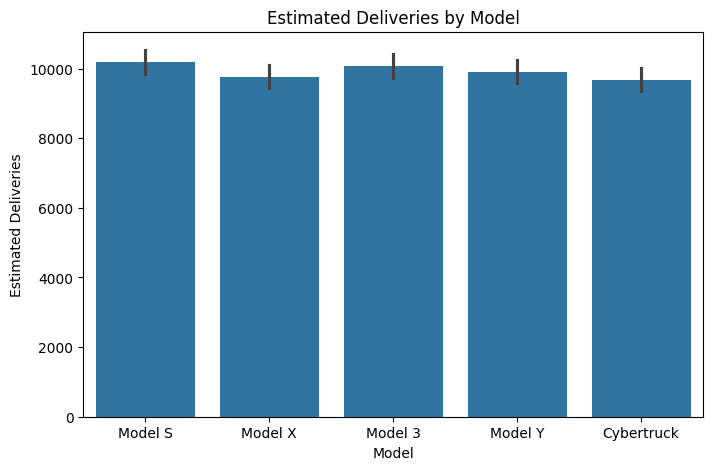

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries'
)

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

The bar chart illustrates the distribution of estimated vehicle deliveries across different Tesla models. This visualization helps identify the most popular and frequently delivered models.

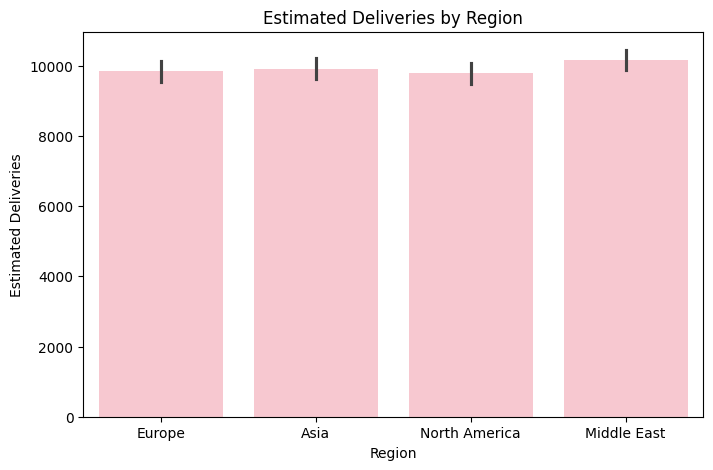

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    color = 'pink'
)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.show()


The regional deliveries chart compares Tesla deliveries across different geographical regions. It provides insights into market demand and regional performance.

# Correlation Heatmap

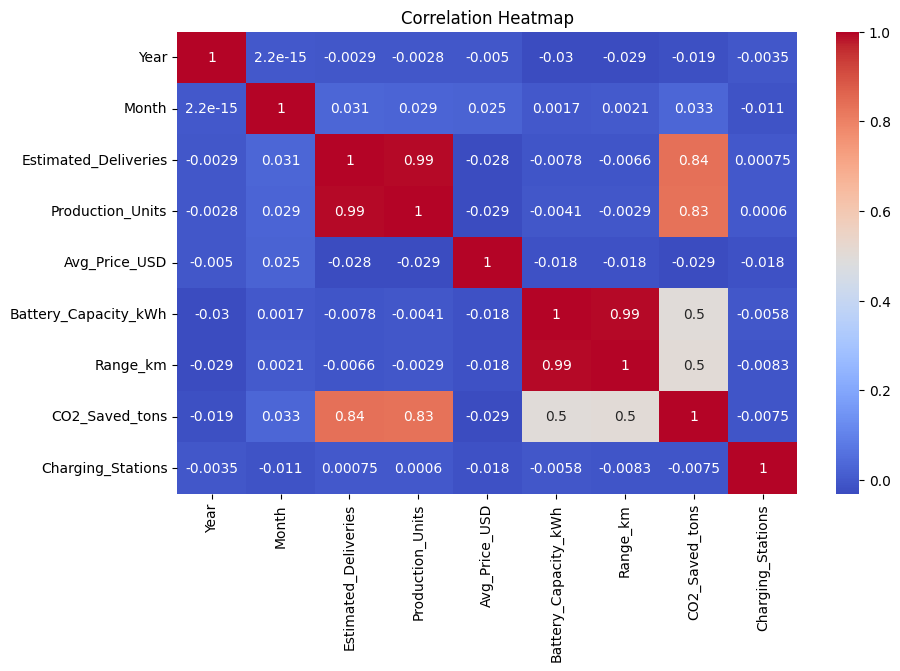

In [6]:
num_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap visualizes relationships among numerical variables. A strong positive correlation was observed between Production_Units and Estimated_Deliveries, indicating that higher production levels are associated with higher delivery volumes.

# Production vs Deliveries Scatter Plot

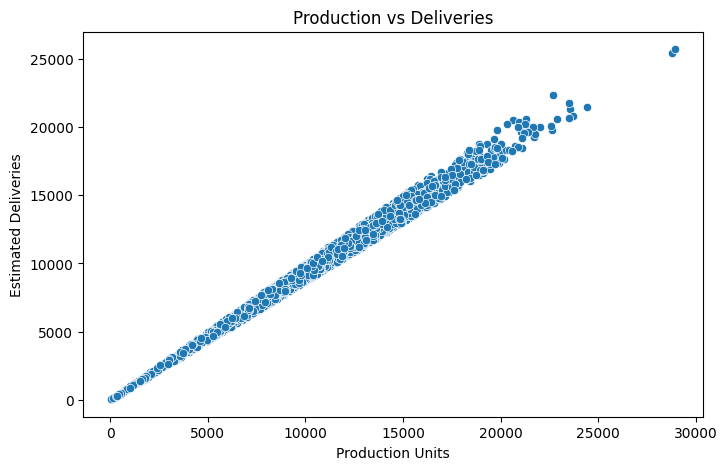

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

The scatter plot demonstrates the relationship between production units and estimated deliveries. The positive trend suggests that production volume is a strong predictor of deliveries

# Time Trend Line

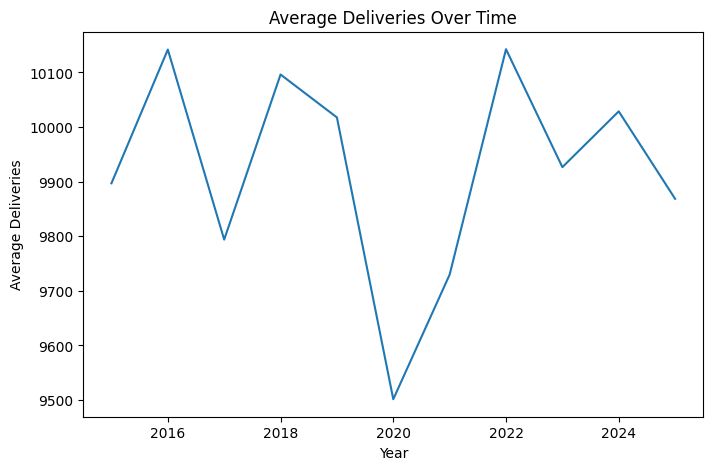

In [8]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=trend,
    x='Year',
    y='Estimated_Deliveries'
)

plt.title("Average Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")

plt.show()

The line chart shows how average deliveries have changed over time. This visualization helps identify long-term growth patterns and delivery trends throughout the year

# Label Encoding

Categorical variables such as Model, Region, and Source_Type were converted into numerical values using Label Encoding. Machine learning algorithms require numerical inputs, making this transformation necessary.

A lag feature (Deliveries_Lag1) was created by shifting Estimated_Deliveries by one time step. This feature captures information from the previous observation and helps model temporal dependencies.

A rolling mean feature (Rolling_Mean_3) was generated using a 3-period moving average. This feature smooths short-term fluctuations and highlights underlying trends in delivery patterns. Missing values introduced during feature creation were replaced with the respective feature means

In [11]:
from sklearn.preprocessing import LabelEncoder

le_model = LabelEncoder()
le_region = LabelEncoder()
le_source = LabelEncoder()

df['Model'] = le_model.fit_transform(df['Model'])
df['Region'] = le_region.fit_transform(df['Region'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

# Lag Mean

In [12]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)

# Rolling Mean

In [13]:
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean()
)

In [14]:
df[['Estimated_Deliveries', 'Deliveries_Lag1']].head()

,Estimated_Deliveries,Deliveries_Lag1
0,17646,9924.959454
1,3797,17646.000000
2,8411,3797.000000
3,6555,8411.000000
4,12374,6555.000000


# 80/20 Split and Linear Regression

In [15]:
print(df[['Estimated_Deliveries',
          'Deliveries_Lag1',
          'Rolling_Mean_3']].head())

   Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0                 17646      9924.959454     9923.677407
1                  3797     17646.000000     9923.677407
2                  8411      3797.000000     9951.333333
3                  6555      8411.000000     6254.333333
4                 12374      6555.000000     9113.333333


In [16]:
y = df['Estimated_Deliveries']
X = df.drop('Estimated_Deliveries', axis=1)

In [17]:
split_idx = int(0.8 * len(df))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test,pred_lr)
)

r2 = r2_score(y_test,pred_lr)

print(mae)
print(rmse)
print(r2)

310.3345215398842
375.5646664534478
0.9908058721380986


The dataset was divided chronologically using index slicing, where the first 80% of observations were used for training and the remaining 20% were used for testing. This approach preserves the temporal order of the data and avoids data leakage.

A Linear Regression model was trained to predict Estimated_Deliveries. The model achieved an R² score of approximately 0.991, indicating that more than 99% of the variation in deliveries is explained by the selected features. The low MAE and RMSE values further demonstrate strong predictive performance.

# Actual vs Predicted

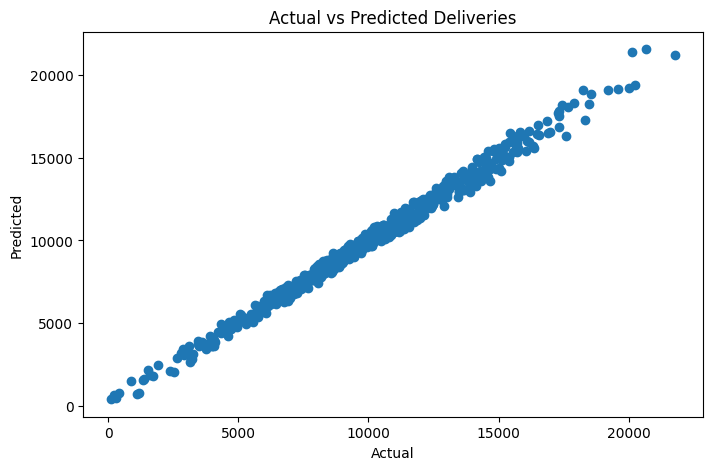

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,pred_lr)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Deliveries")

plt.show()

The Actual vs Predicted scatter plot shows that predicted values closely follow actual delivery values. The points cluster near the diagonal trend, indicating accurate predictions and good model fit.

# 5-Fold Cross Validation

In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv_scores)

print("Mean:",cv_scores.mean())
print("Std:",cv_scores.std())

[0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]
Mean: 0.9903849476659861
Std: 0.00046153530925534015


Five-fold cross validation was performed to evaluate model stability and generalization performance. The dataset was divided into five subsets, with each subset serving as a validation set once. The mean R² score and standard deviation were calculated to assess consistency across folds. The results indicate that the model performs reliably on different data partitions

# Random Forest and GridSearchCV

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='r2')

In [23]:
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 50}


**Prediction:**

In [24]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print(
    r2_score(y_test,rf_pred)
)

0.99015903323468


A Random Forest Regressor was optimized using GridSearchCV with different combinations of n_estimators and max_depth values. The best-performing model was selected automatically based on cross-validation performance.

The Random Forest model achieved an R² score greater than 0.99, demonstrating excellent predictive capability. Although Linear Regression slightly outperformed Random Forest on this dataset, both models achieved very high accuracy

# Top 10 Feature Importances

In [25]:
imp = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
})

imp = imp.sort_values(
    by='Importance',
    ascending=False
)

top10 = imp.head(10)

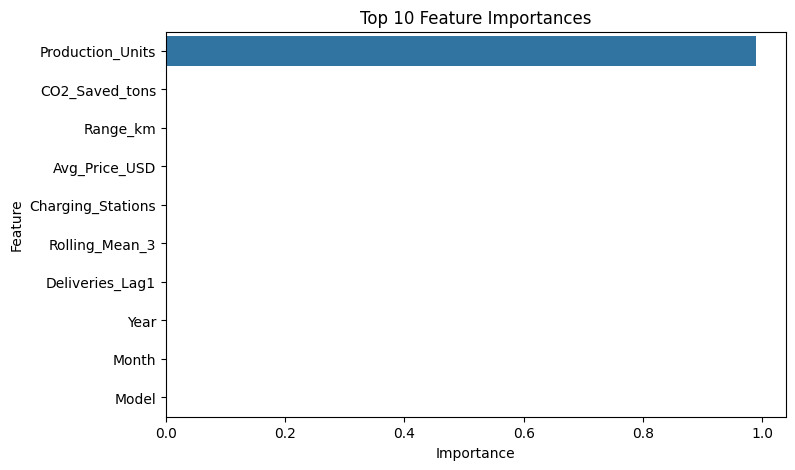

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.show()

In [27]:
print(df['Production_Units'].corr(df['Estimated_Deliveries']))

0.9942343488939529


In [28]:
top10

,Feature,Importance
4,Production_Units,0.990055
8,CO2_Saved_tons,0.002163
7,Range_km,0.001221
5,Avg_Price_USD,0.001040
10,Charging_Stations,0.001004
12,Rolling_Mean_3,0.000955
11,Deliveries_Lag1,0.000923
0,Year,0.000888
1,Month,0.000668
3,Model,0.000357


Feature importance analysis revealed that Production_Units is the most influential predictor of Estimated_Deliveries. This finding aligns with domain expectations because vehicle deliveries are strongly dependent on production volume. Other features contributed comparatively less to the prediction process.


# ADF Test

In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    df['Estimated_Deliveries']
)

print("ADF Statistic:",result[0])
print("p-value:",result[1])

ADF Statistic: -53.82661259715622
p-value: 0.0


The Augmented Dickey-Fuller (ADF) test was performed on the Estimated_Deliveries series to check stationarity. The obtained p-value was 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis of non-stationarity is rejected. This indicates that the Estimated_Deliveries series is stationary and does not exhibit a unit root.

In [30]:
if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-stationary")

Stationary


# Forecast Comparison Table

In [31]:
forecast = pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':rf_pred
})

forecast['Error_%'] = (
    abs(
        forecast['Actual']
        -
        forecast['Predicted']
    )
    /
    forecast['Actual']
) * 100

forecast.head(20)

,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


The forecast comparison table presents the first 20 records from the test dataset. The predicted delivery values are generally close to the actual values, with most percentage errors remaining below 6%. This indicates that the trained Random Forest model is able to capture the relationship between production, pricing, battery capacity, and other features effectively, resulting in accurate delivery forecasts.


# Conclusion
This project analyzed Tesla delivery and production data from 2015–2025 using exploratory data analysis, feature engineering, and predictive modeling techniques. Strong relationships were observed between production units and estimated deliveries. Both Linear Regression and Random Forest models achieved excellent predictive performance, with R² values exceeding 0.99. The ADF test confirmed stationarity of the delivery series, and feature importance analysis identified Production_Units as the dominant predictor. Overall, the analysis demonstrates the effectiveness of machine learning methods for forecasting Tesla delivery trends.